In [7]:
import pandas as pd 
import numpy as np
from pathlib import Path

In [8]:
import os 
from pathlib import Path 
path=Path.cwd().parent


In [9]:
(path/'data/train_flood.csv').exists()

True

In [10]:
df=pd.read_csv(path/'data/train_flood.csv')
df1=pd.read_csv(path/'data/test_flood.csv')

In [11]:
df.head()

,row_id,month,day_of_year,streamflow_today_cumecs,streamflow_anomaly_zscore,flow_rate_of_change,flow_velocity_km_per_day,antecedent_rain_3d_sum,antecedent_rain_7d_sum,antecedent_rain_15d_sum,...,slope_scaled,slope_uav_scaled,forest_cover_scaled,urban_cover_scaled,rain_soilmoisture_interaction,rain_urban_interaction,rain_slope_interaction,rain_basinsize_interaction,uparea_rain_interaction,streamflow_tomorrow_cumecs
0,0,2,3,51.84180,-0.554512,-0.406627,-1.649524,0.0,0.0,0.0,...,-0.564147,0.638676,-0.347207,-1.043051,-0.518025,-0.514179,-0.514108,-0.519493,-0.472262,51.435061
1,1,2,3,570.75726,-0.594236,-5.728960,0.206959,0.0,0.0,0.0,...,-0.184717,0.039940,-0.347207,0.183875,-0.518025,-0.514179,-0.514108,-0.519493,-0.472262,565.028190
2,2,2,3,45.45640,-1.113376,-0.192057,-1.649524,0.0,0.0,0.0,...,-0.564147,-1.066421,-0.347207,-1.043051,-0.518025,-0.514179,-0.514108,-0.519493,-0.472262,45.264231
3,3,2,3,405.39710,-0.729036,-2.480840,0.769118,0.0,0.0,0.0,...,0.068236,2.278693,4.526986,-1.533821,-0.518025,-0.514179,-0.514108,-0.519493,-0.472262,402.916149
4,4,2,3,2289.59030,-1.284924,-16.203800,-0.256761,0.0,0.0,0.0,...,-0.311194,-0.728005,-0.347207,0.183875,-0.518025,-0.514179,-0.514108,-0.519493,-0.472262,2273.386393


In [12]:
df.columns

Index(['row_id', 'month', 'day_of_year', 'streamflow_today_cumecs',
       'streamflow_anomaly_zscore', 'flow_rate_of_change',
       'flow_velocity_km_per_day', 'antecedent_rain_3d_sum',
       'antecedent_rain_7d_sum', 'antecedent_rain_15d_sum',
       'antecedent_rain_30d_sum', 'antecedent_rain_60d', 'antecedent_rain_ewm',
       'rainfall_anomaly_zscore', 'upstream_rain_mean_scaled',
       'upstream_rain_weighted_scaled', 'upstream_rain_lagged_dist_sink',
       'soil_saturation_score', 'antecedent_saturation_interaction',
       'is_post_monsoon_saturated', 'monsoon_intensity',
       'monsoon_cumulative_rain', 'dist_to_outlet_scaled',
       'upstream_area_scaled', 'slope_scaled', 'slope_uav_scaled',
       'forest_cover_scaled', 'urban_cover_scaled',
       'rain_soilmoisture_interaction', 'rain_urban_interaction',
       'rain_slope_interaction', 'rain_basinsize_interaction',
       'uparea_rain_interaction', 'streamflow_tomorrow_cumecs'],
      dtype='object')

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
Id=df1['row_id']

In [15]:
df.drop('row_id',axis=1,inplace=True)
df1.drop('row_id',axis=1,inplace=True)

In [16]:
df.head()

,month,day_of_year,streamflow_today_cumecs,streamflow_anomaly_zscore,flow_rate_of_change,flow_velocity_km_per_day,antecedent_rain_3d_sum,antecedent_rain_7d_sum,antecedent_rain_15d_sum,antecedent_rain_30d_sum,...,slope_scaled,slope_uav_scaled,forest_cover_scaled,urban_cover_scaled,rain_soilmoisture_interaction,rain_urban_interaction,rain_slope_interaction,rain_basinsize_interaction,uparea_rain_interaction,streamflow_tomorrow_cumecs
0,2,3,51.84180,-0.554512,-0.406627,-1.649524,0.0,0.0,0.0,0.0,...,-0.564147,0.638676,-0.347207,-1.043051,-0.518025,-0.514179,-0.514108,-0.519493,-0.472262,51.435061
1,2,3,570.75726,-0.594236,-5.728960,0.206959,0.0,0.0,0.0,0.0,...,-0.184717,0.039940,-0.347207,0.183875,-0.518025,-0.514179,-0.514108,-0.519493,-0.472262,565.028190
2,2,3,45.45640,-1.113376,-0.192057,-1.649524,0.0,0.0,0.0,0.0,...,-0.564147,-1.066421,-0.347207,-1.043051,-0.518025,-0.514179,-0.514108,-0.519493,-0.472262,45.264231
3,2,3,405.39710,-0.729036,-2.480840,0.769118,0.0,0.0,0.0,0.0,...,0.068236,2.278693,4.526986,-1.533821,-0.518025,-0.514179,-0.514108,-0.519493,-0.472262,402.916149
4,2,3,2289.59030,-1.284924,-16.203800,-0.256761,0.0,0.0,0.0,0.0,...,-0.311194,-0.728005,-0.347207,0.183875,-0.518025,-0.514179,-0.514108,-0.519493,-0.472262,2273.386393


# Using cylce for month column

In [17]:
df['month_cos']=np.cos(2*np.pi*df['month']/12 )
df['month_sin']=np.sin(2*np.pi*df['month']/12 )

df1['month_cos']=np.cos(2*np.pi*df1['month']/12 )
df1['month_sin']=np.sin(2*np.pi*df1['month']/12 )

In [18]:
df.drop('month',axis=1,inplace=True)
df1.drop('month',axis=1,inplace=True)

## for day of year

In [19]:
df['dayofyear_cos']=np.cos(2*np.pi*df['day_of_year']/365 )
df['dayofyear_sin']=np.sin(2*np.pi*df['day_of_year']/365)

df1['dayofyear_cos']=np.cos(2*np.pi*df1['day_of_year']/365 )
df1['dayofyear_sin']=np.sin(2*np.pi*df1['day_of_year']/365)

In [20]:
df.drop('day_of_year',axis=1,inplace=True)
df1.drop('day_of_year',axis=1,inplace=True)

In [21]:
df.head()

,streamflow_today_cumecs,streamflow_anomaly_zscore,flow_rate_of_change,flow_velocity_km_per_day,antecedent_rain_3d_sum,antecedent_rain_7d_sum,antecedent_rain_15d_sum,antecedent_rain_30d_sum,antecedent_rain_60d,antecedent_rain_ewm,...,rain_soilmoisture_interaction,rain_urban_interaction,rain_slope_interaction,rain_basinsize_interaction,uparea_rain_interaction,streamflow_tomorrow_cumecs,month_cos,month_sin,dayofyear_cos,dayofyear_sin
0,51.84180,-0.554512,-0.406627,-1.649524,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.518025,-0.514179,-0.514108,-0.519493,-0.472262,51.435061,0.5,0.866025,0.998667,0.05162
1,570.75726,-0.594236,-5.728960,0.206959,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.518025,-0.514179,-0.514108,-0.519493,-0.472262,565.028190,0.5,0.866025,0.998667,0.05162
2,45.45640,-1.113376,-0.192057,-1.649524,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.518025,-0.514179,-0.514108,-0.519493,-0.472262,45.264231,0.5,0.866025,0.998667,0.05162
3,405.39710,-0.729036,-2.480840,0.769118,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.518025,-0.514179,-0.514108,-0.519493,-0.472262,402.916149,0.5,0.866025,0.998667,0.05162
4,2289.59030,-1.284924,-16.203800,-0.256761,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.518025,-0.514179,-0.514108,-0.519493,-0.472262,2273.386393,0.5,0.866025,0.998667,0.05162


In [22]:
import seaborn as sns 
import matplotlib.pyplot as plt 

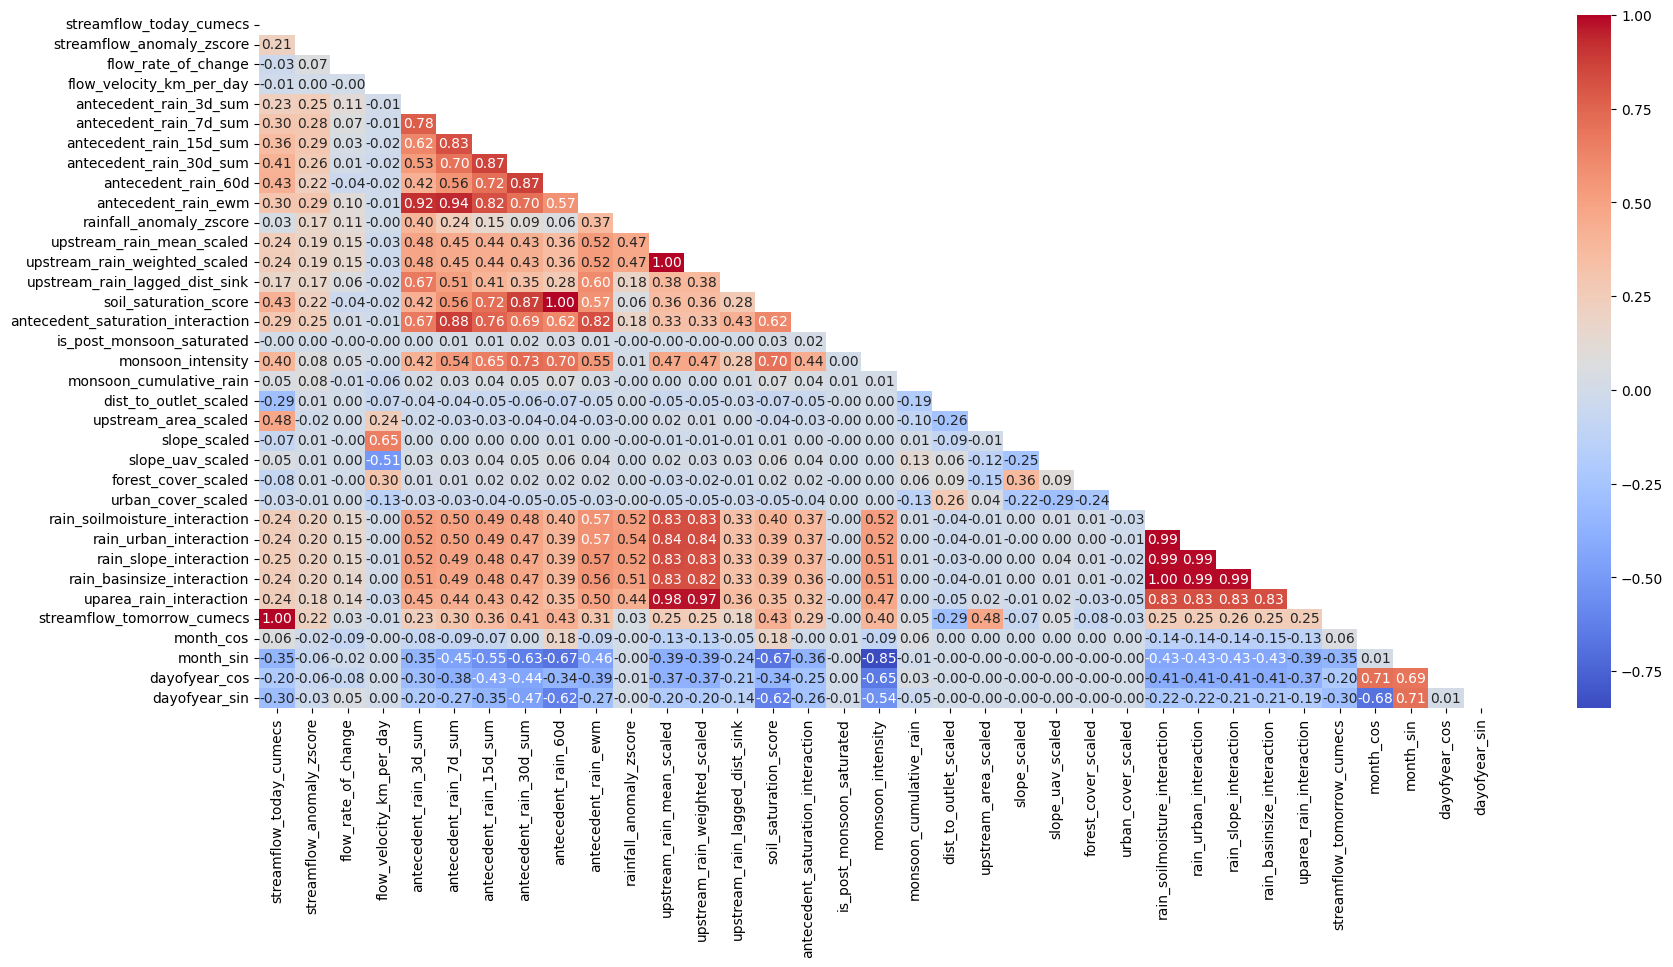

In [23]:
plt.figure(figsize=(20,9))
sns.heatmap(df.corr(),annot=True,fmt='.2f',cmap='coolwarm',mask=np.triu(np.ones_like(df.corr(),dtype=bool),k=0))
plt.show()

In [24]:
df1.columns

Index(['streamflow_today_cumecs', 'streamflow_anomaly_zscore',
       'flow_rate_of_change', 'flow_velocity_km_per_day',
       'antecedent_rain_3d_sum', 'antecedent_rain_7d_sum',
       'antecedent_rain_15d_sum', 'antecedent_rain_30d_sum',
       'antecedent_rain_60d', 'antecedent_rain_ewm', 'rainfall_anomaly_zscore',
       'upstream_rain_mean_scaled', 'upstream_rain_weighted_scaled',
       'upstream_rain_lagged_dist_sink', 'soil_saturation_score',
       'antecedent_saturation_interaction', 'is_post_monsoon_saturated',
       'monsoon_intensity', 'monsoon_cumulative_rain', 'dist_to_outlet_scaled',
       'upstream_area_scaled', 'slope_scaled', 'slope_uav_scaled',
       'forest_cover_scaled', 'urban_cover_scaled',
       'rain_soilmoisture_interaction', 'rain_urban_interaction',
       'rain_slope_interaction', 'rain_basinsize_interaction',
       'uparea_rain_interaction', 'month_cos', 'month_sin', 'dayofyear_cos',
       'dayofyear_sin'],
      dtype='object')

In [25]:
# single merged interaction
df['merged_rain_interaction'] = df[[
    'rain_soilmoisture_interaction', 
    'rain_urban_interaction', 
    'rain_slope_interaction', 
    'rain_basinsize_interaction',
    'uparea_rain_interaction',
    'antecedent_saturation_interaction'
]].mean(axis=1)

df1['merged_rain_interaction'] = df1[[
    'rain_soilmoisture_interaction', 
    'rain_urban_interaction', 
    'rain_slope_interaction', 
    'rain_basinsize_interaction',
    'uparea_rain_interaction',
    'antecedent_saturation_interaction'
]].mean(axis=1)

In [26]:
# single merged scaled
df['upstream_rain_weighted' ]=(df['upstream_rain_mean_scaled']*0.6)+(df['upstream_rain_weighted_scaled']*0.4)
df1['upstream_rain_weighted' ]=(df1['upstream_rain_mean_scaled']*0.6)+(df1['upstream_rain_weighted_scaled']*0.4)

In [27]:
drop_cols=[
    'rain_soilmoisture_interaction', 
    'rain_urban_interaction', 
    'rain_slope_interaction', 
    'rain_basinsize_interaction',
    'uparea_rain_interaction',
    'antecedent_saturation_interaction',
    
    'upstream_rain_mean_scaled',
    'upstream_rain_weighted_scaled'
]

In [28]:
df.drop(columns=drop_cols,axis=1,inplace=True)
df1.drop(columns=drop_cols,axis=1,inplace=True)
df.head()

,streamflow_today_cumecs,streamflow_anomaly_zscore,flow_rate_of_change,flow_velocity_km_per_day,antecedent_rain_3d_sum,antecedent_rain_7d_sum,antecedent_rain_15d_sum,antecedent_rain_30d_sum,antecedent_rain_60d,antecedent_rain_ewm,...,slope_uav_scaled,forest_cover_scaled,urban_cover_scaled,streamflow_tomorrow_cumecs,month_cos,month_sin,dayofyear_cos,dayofyear_sin,merged_rain_interaction,upstream_rain_weighted
0,51.84180,-0.554512,-0.406627,-1.649524,0.0,0.0,0.0,0.0,0.0,0.0,...,0.638676,-0.347207,-1.043051,51.435061,0.5,0.866025,0.998667,0.05162,-0.423011,-0.459854
1,570.75726,-0.594236,-5.728960,0.206959,0.0,0.0,0.0,0.0,0.0,0.0,...,0.039940,-0.347207,0.183875,565.028190,0.5,0.866025,0.998667,0.05162,-0.423011,-0.459854
2,45.45640,-1.113376,-0.192057,-1.649524,0.0,0.0,0.0,0.0,0.0,0.0,...,-1.066421,-0.347207,-1.043051,45.264231,0.5,0.866025,0.998667,0.05162,-0.423011,-0.459854
3,405.39710,-0.729036,-2.480840,0.769118,0.0,0.0,0.0,0.0,0.0,0.0,...,2.278693,4.526986,-1.533821,402.916149,0.5,0.866025,0.998667,0.05162,-0.423011,-0.459854
4,2289.59030,-1.284924,-16.203800,-0.256761,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.728005,-0.347207,0.183875,2273.386393,0.5,0.866025,0.998667,0.05162,-0.423011,-0.459854


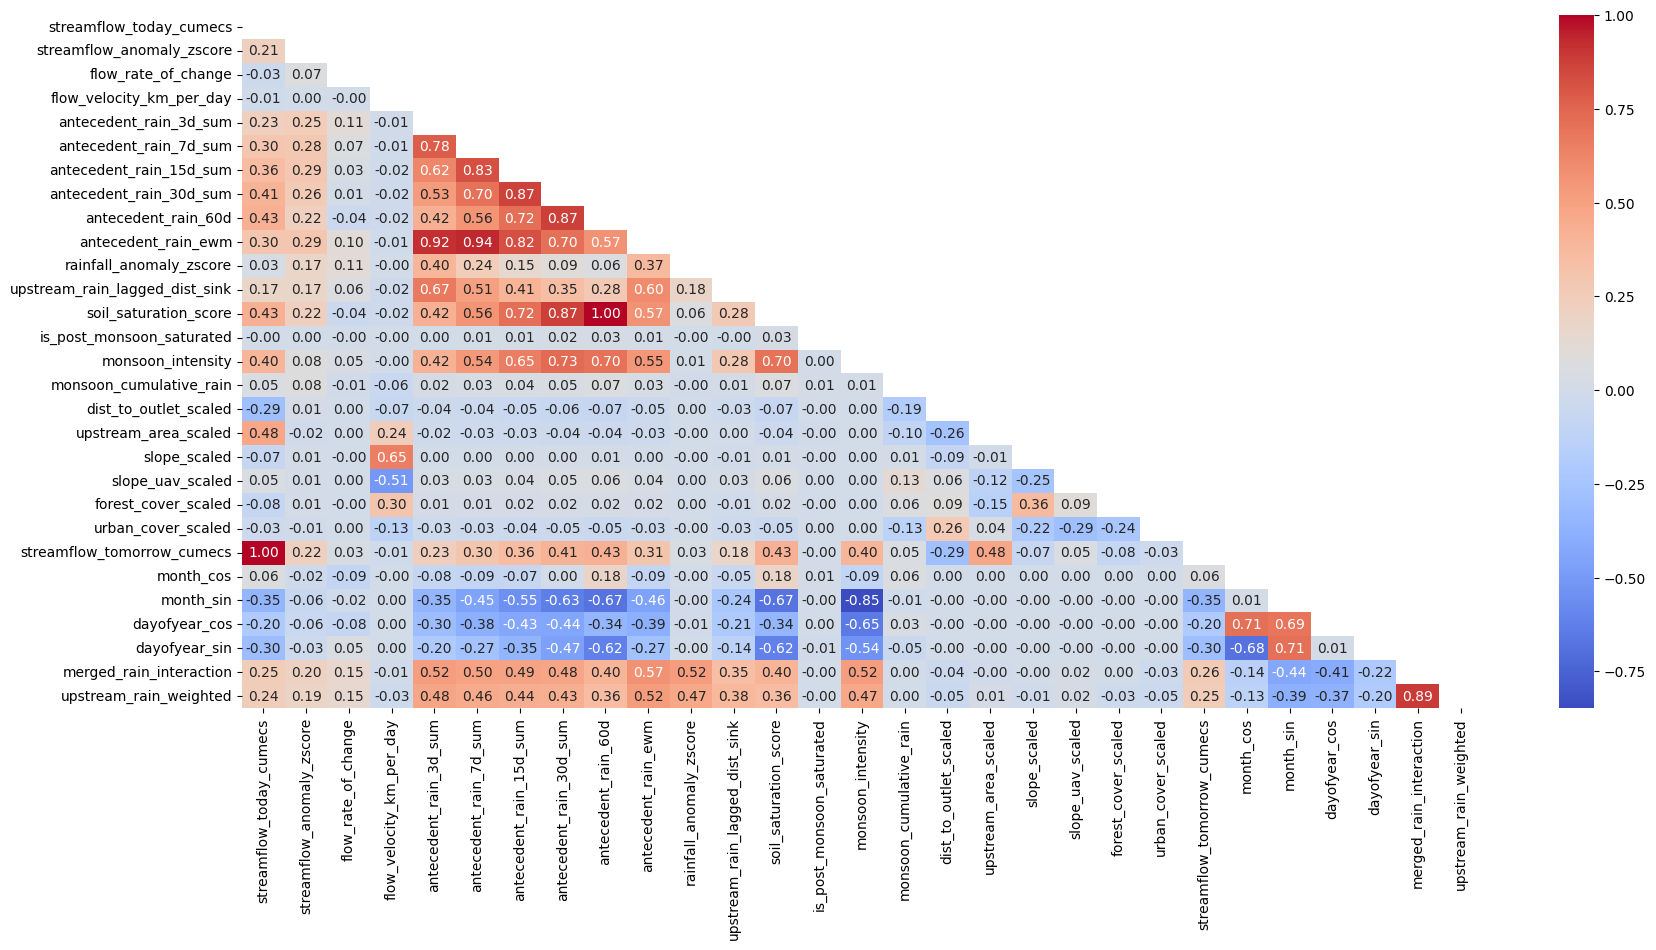

In [29]:
plt.figure(figsize=(20,9))
sns.heatmap(df.corr(),annot=True,fmt='.2f',cmap='coolwarm',mask=np.triu(np.ones_like(df.corr(),dtype=bool),k=0))
plt.show()

In [30]:
# giving higher weight to recent rain
df['antecedent_total'] = (df['antecedent_rain_3d_sum'] * 0.4) + (df['antecedent_rain_7d_sum'] * 0.3) + (df['antecedent_rain_15d_sum'] * 0.1)+(df['antecedent_rain_30d_sum']*0.05)+(df['antecedent_rain_60d']*0.05)+(df['antecedent_rain_ewm']*0.1)
df1['antecedent_total'] = (df1['antecedent_rain_3d_sum'] * 0.4) + (df1['antecedent_rain_7d_sum'] * 0.3) + (df1['antecedent_rain_15d_sum'] * 0.1)+(df1['antecedent_rain_30d_sum']*0.05)+(df1['antecedent_rain_60d']*0.05)+(df1['antecedent_rain_ewm']*0.1)

In [31]:
antecedent_cols=[
    'antecedent_rain_3d_sum',
    'antecedent_rain_7d_sum',
    'antecedent_rain_15d_sum',
    'antecedent_rain_30d_sum',
    'antecedent_rain_60d',
    'antecedent_rain_ewm' 
]

In [32]:
df.drop(columns=antecedent_cols,axis=1,inplace=True)
df1.drop(columns=antecedent_cols,axis=1,inplace=True)
df.head()

,streamflow_today_cumecs,streamflow_anomaly_zscore,flow_rate_of_change,flow_velocity_km_per_day,rainfall_anomaly_zscore,upstream_rain_lagged_dist_sink,soil_saturation_score,is_post_monsoon_saturated,monsoon_intensity,monsoon_cumulative_rain,...,forest_cover_scaled,urban_cover_scaled,streamflow_tomorrow_cumecs,month_cos,month_sin,dayofyear_cos,dayofyear_sin,merged_rain_interaction,upstream_rain_weighted,antecedent_total
0,51.84180,-0.554512,-0.406627,-1.649524,-0.274649,-0.231412,0.0,0,0.0,0.0,...,-0.347207,-1.043051,51.435061,0.5,0.866025,0.998667,0.05162,-0.423011,-0.459854,0.0
1,570.75726,-0.594236,-5.728960,0.206959,-0.220278,-0.231412,0.0,0,0.0,0.0,...,-0.347207,0.183875,565.028190,0.5,0.866025,0.998667,0.05162,-0.423011,-0.459854,0.0
2,45.45640,-1.113376,-0.192057,-1.649524,-0.311483,-0.231412,0.0,0,0.0,0.0,...,-0.347207,-1.043051,45.264231,0.5,0.866025,0.998667,0.05162,-0.423011,-0.459854,0.0
3,405.39710,-0.729036,-2.480840,0.769118,-0.228279,-0.231412,0.0,0,0.0,0.0,...,4.526986,-1.533821,402.916149,0.5,0.866025,0.998667,0.05162,-0.423011,-0.459854,0.0
4,2289.59030,-1.284924,-16.203800,-0.256761,-0.282414,-0.231412,0.0,0,0.0,0.0,...,-0.347207,0.183875,2273.386393,0.5,0.866025,0.998667,0.05162,-0.423011,-0.459854,0.0


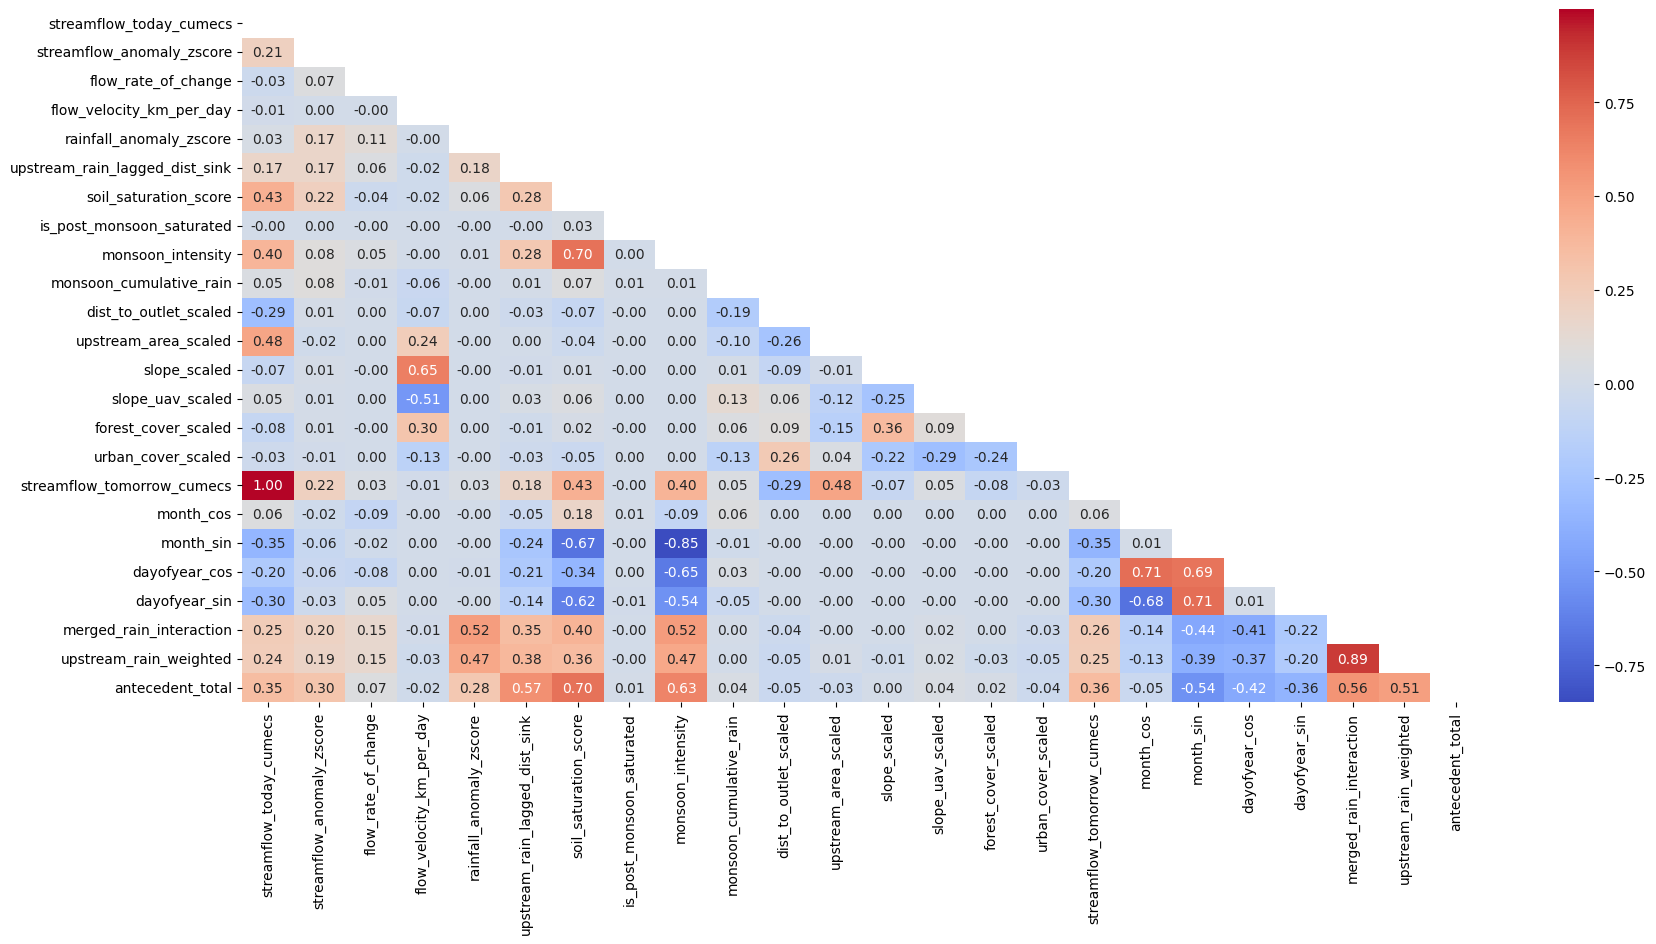

In [33]:
plt.figure(figsize=(20,9))
df.corr()
sns.heatmap(df.corr(),annot=True,fmt='.2f',cmap='coolwarm',mask=np.triu(np.ones_like(df.corr(),dtype=bool),k=0))
plt.show()

In [34]:
df.columns

Index(['streamflow_today_cumecs', 'streamflow_anomaly_zscore',
       'flow_rate_of_change', 'flow_velocity_km_per_day',
       'rainfall_anomaly_zscore', 'upstream_rain_lagged_dist_sink',
       'soil_saturation_score', 'is_post_monsoon_saturated',
       'monsoon_intensity', 'monsoon_cumulative_rain', 'dist_to_outlet_scaled',
       'upstream_area_scaled', 'slope_scaled', 'slope_uav_scaled',
       'forest_cover_scaled', 'urban_cover_scaled',
       'streamflow_tomorrow_cumecs', 'month_cos', 'month_sin', 'dayofyear_cos',
       'dayofyear_sin', 'merged_rain_interaction', 'upstream_rain_weighted',
       'antecedent_total'],
      dtype='object')

In [35]:
df['merged_upstream']=(df['merged_rain_interaction']*0.6)+(df['upstream_rain_weighted']*0.4)
df1['merged_upstream']=(df1['merged_rain_interaction']*0.6)+(df1['upstream_rain_weighted']*0.4)

In [36]:
df.drop(columns={'merged_rain_interaction','upstream_rain_weighted'},axis=1,inplace=True)
df1.drop(columns={'merged_rain_interaction','upstream_rain_weighted'},axis=1,inplace=True)
df.head()

,streamflow_today_cumecs,streamflow_anomaly_zscore,flow_rate_of_change,flow_velocity_km_per_day,rainfall_anomaly_zscore,upstream_rain_lagged_dist_sink,soil_saturation_score,is_post_monsoon_saturated,monsoon_intensity,monsoon_cumulative_rain,...,slope_uav_scaled,forest_cover_scaled,urban_cover_scaled,streamflow_tomorrow_cumecs,month_cos,month_sin,dayofyear_cos,dayofyear_sin,antecedent_total,merged_upstream
0,51.84180,-0.554512,-0.406627,-1.649524,-0.274649,-0.231412,0.0,0,0.0,0.0,...,0.638676,-0.347207,-1.043051,51.435061,0.5,0.866025,0.998667,0.05162,0.0,-0.437748
1,570.75726,-0.594236,-5.728960,0.206959,-0.220278,-0.231412,0.0,0,0.0,0.0,...,0.039940,-0.347207,0.183875,565.028190,0.5,0.866025,0.998667,0.05162,0.0,-0.437748
2,45.45640,-1.113376,-0.192057,-1.649524,-0.311483,-0.231412,0.0,0,0.0,0.0,...,-1.066421,-0.347207,-1.043051,45.264231,0.5,0.866025,0.998667,0.05162,0.0,-0.437748
3,405.39710,-0.729036,-2.480840,0.769118,-0.228279,-0.231412,0.0,0,0.0,0.0,...,2.278693,4.526986,-1.533821,402.916149,0.5,0.866025,0.998667,0.05162,0.0,-0.437748
4,2289.59030,-1.284924,-16.203800,-0.256761,-0.282414,-0.231412,0.0,0,0.0,0.0,...,-0.728005,-0.347207,0.183875,2273.386393,0.5,0.866025,0.998667,0.05162,0.0,-0.437748


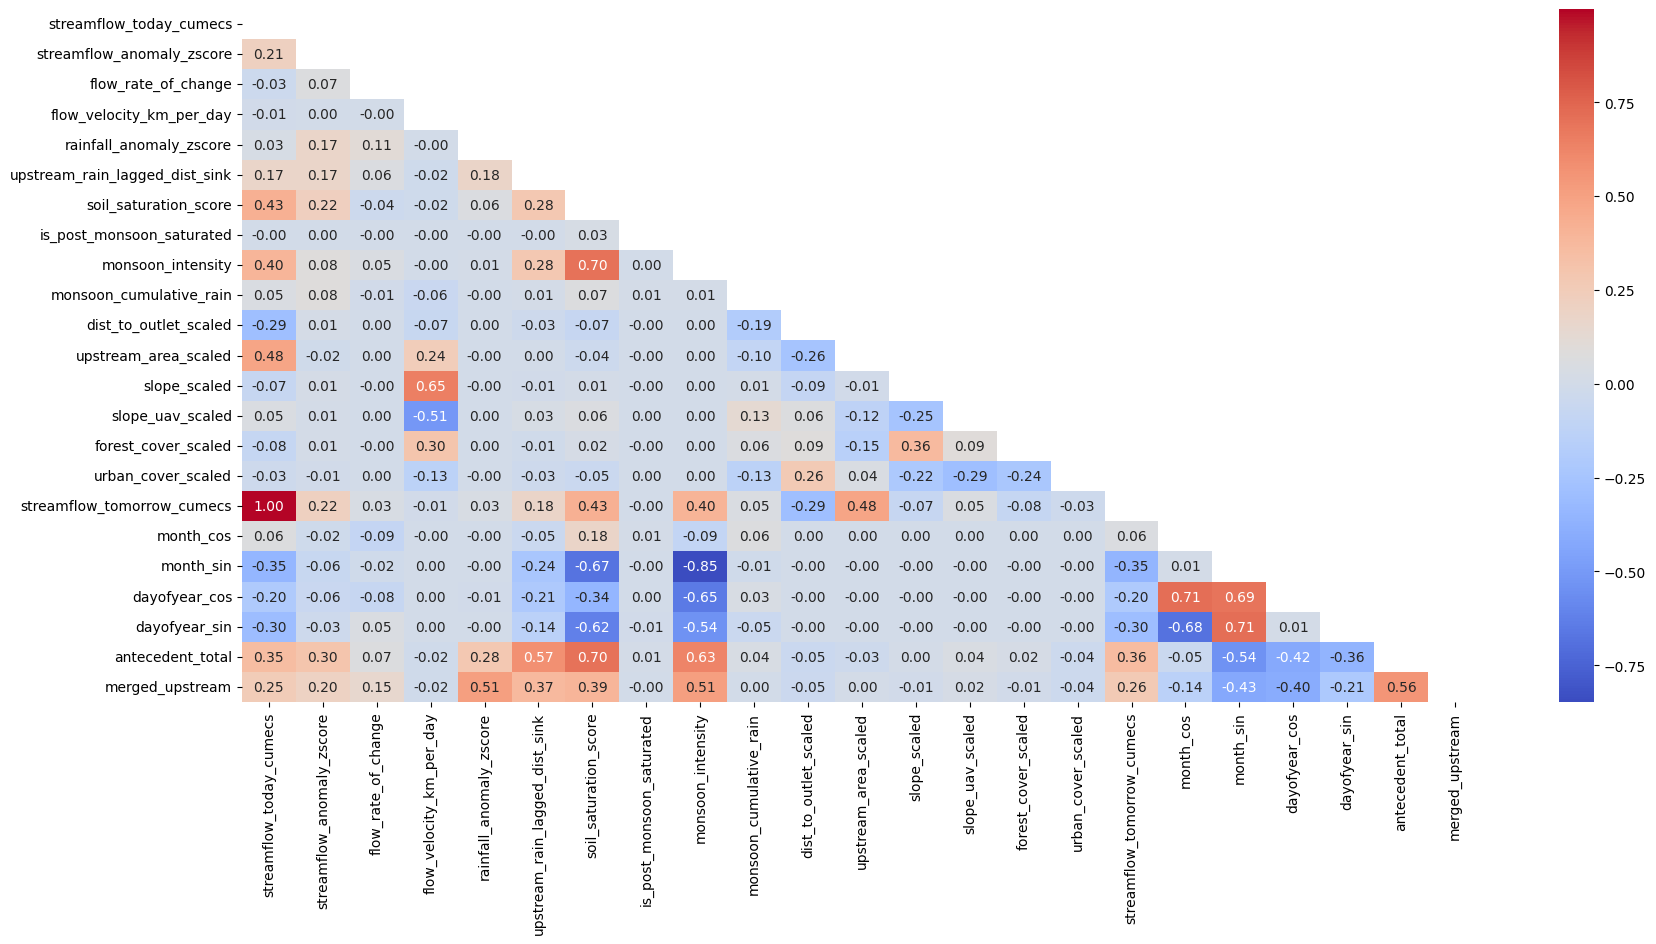

In [37]:
plt.figure(figsize=(20,9))
sns.heatmap(df.corr(),annot=True,fmt='.2f',cmap='coolwarm',mask=np.triu(np.ones_like(df.corr(),dtype=bool),k=0))
plt.show()

In [38]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split,GridSearchCV,TimeSeriesSplit
from sklearn.metrics import accuracy_score ,mean_squared_error,r2_score,mean_absolute_error

In [39]:
sc=StandardScaler()

In [40]:
X=df.drop('streamflow_tomorrow_cumecs',axis=1)
y=df['streamflow_tomorrow_cumecs']

In [41]:
split=int(df.shape[0]*0.8)

In [42]:
train=df.iloc[:split]
test=df.iloc[split:]

In [43]:
X_train=train.drop('streamflow_tomorrow_cumecs',axis=1)
y_train=train['streamflow_tomorrow_cumecs']

X_test=test.drop('streamflow_tomorrow_cumecs',axis=1)
y_test=test['streamflow_tomorrow_cumecs']

# Base error 

In [44]:
base=X_test['streamflow_today_cumecs']
mean_absolute_error(y_test,base)

43.755939854379925

In [45]:
X_train_scaled=sc.fit_transform(X_train)
X_test_scaled=sc.transform(X_test)

df1_scaled=sc.transform(df1)

In [46]:
from sklearn.ensemble import RandomForestRegressor 
from xgboost import XGBRegressor 

In [47]:
xgb=XGBRegressor()

# Using GridSearchCV

In [48]:
parameters={
    'n_estimators':[100,200],
    'max_depth':[4,6],
    'learning_rate':[0.05,0.1],
    'subsample':[0.8]
}

In [49]:
tscv=TimeSeriesSplit(n_splits=3)

In [50]:
grid_search=GridSearchCV(
    estimator=xgb,
    param_grid=parameters,
    cv=tscv,
    scoring='neg_mean_absolute_error' ,
    n_jobs=1,
    verbose=2
)

In [51]:
grid_search.fit(X_train_scaled,y_train)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
[CV] END learning_rate=0.05, max_depth=4, n_estimators=100, subsample=0.8; total time=   1.3s
[CV] END learning_rate=0.05, max_depth=4, n_estimators=100, subsample=0.8; total time=   2.4s
[CV] END learning_rate=0.05, max_depth=4, n_estimators=100, subsample=0.8; total time=   3.4s
[CV] END learning_rate=0.05, max_depth=4, n_estimators=200, subsample=0.8; total time=   1.9s
[CV] END learning_rate=0.05, max_depth=4, n_estimators=200, subsample=0.8; total time=   3.6s
[CV] END learning_rate=0.05, max_depth=4, n_estimators=200, subsample=0.8; total time=   6.0s
[CV] END learning_rate=0.05, max_depth=6, n_estimators=100, subsample=0.8; total time=   1.5s
[CV] END learning_rate=0.05, max_depth=6, n_estimators=100, subsample=0.8; total time=   2.9s
[CV] END learning_rate=0.05, max_depth=6, n_estimators=100, subsample=0.8; total time=   4.2s
[CV] END learning_rate=0.05, max_depth=6, n_estimators=200, subsample=0.8; total time=   2.1s


,estimator,"XGBRegressor(...ree=None, ...)"
,param_grid,"{'learning_rate': [0.05, 0.1], 'max_depth': [4, 6], 'n_estimators': [100, 200], 'subsample': [0.8]}"
,scoring,'neg_mean_absolute_error'
,n_jobs,1
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'reg:squarederror'


In [52]:
print(grid_search.best_params_)


{'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100, 'subsample': 0.8}


In [53]:
best_xgb_params=grid_search.best_estimator_.predict(X_test_scaled)

In [54]:
mean_absolute_error(y_test,best_xgb_params)

17.92273217928

In [55]:
cv_train=grid_search.best_estimator_.predict(X_train_scaled)

In [56]:
mean_absolute_error(y_train,cv_train)

16.05948386241543

# Prediction using xgb

In [57]:
xgb.fit(X_train_scaled,y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


## Test error

In [58]:
xgb_pred=xgb.predict(X_test_scaled)

In [59]:
mean_absolute_error(y_test,xgb_pred)

19.874209184320414

## Train error 

In [60]:
train_xgb=xgb.predict(X_train_scaled)

In [61]:
mean_absolute_error(y_train,train_xgb)

16.18480860758931

In [62]:
r2_score(y_test,xgb_pred )

0.9987115443590571

## Catboost

In [63]:
from catboost import CatBoostRegressor

cat = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    verbose=100
)

In [64]:
cat.fit(X_train_scaled,y_train)

0:	learn: 2058.9851987	total: 227ms	remaining: 3m 46s
100:	learn: 133.6762170	total: 8.52s	remaining: 1m 15s
200:	learn: 90.6963784	total: 17.7s	remaining: 1m 10s
300:	learn: 75.0157964	total: 26.5s	remaining: 1m 1s
400:	learn: 66.8983893	total: 35.5s	remaining: 53s
500:	learn: 61.6318742	total: 44.3s	remaining: 44.1s
600:	learn: 57.6615751	total: 53.5s	remaining: 35.5s
700:	learn: 54.6144811	total: 1m 2s	remaining: 26.7s
800:	learn: 51.9873220	total: 1m 11s	remaining: 17.8s
900:	learn: 49.8510706	total: 1m 20s	remaining: 8.83s
999:	learn: 48.1340813	total: 1m 28s	remaining: 0us


CatBoostRegressor(depth=8, iterations=1000, learning_rate=0.05, loss_function='RMSE', verbose=100)

## Test error 

In [65]:
cat_pred=cat.predict(X_test_scaled)

In [66]:
mean_absolute_error(y_test,cat_pred)

18.440721344348187

## Train error 

In [67]:
cat_train=cat.predict(X_train_scaled)

In [68]:
mean_absolute_error(y_train,cat_train)

16.191021270757414

# Using LightGBM

In [69]:
from lightgbm import LGBMRegressor

In [70]:
light=LGBMRegressor()

In [71]:
light.fit(X_train_scaled,y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.047434 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3581
[LightGBM] [Info] Number of data points in the train set: 2056844, number of used features: 22
[LightGBM] [Info] Start training from score 1204.228734


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [72]:
light_pred=light.predict(X_test_scaled)

c:\Users\vk\anaconda3\envs\tfenv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [73]:
mean_absolute_error(y_test,light_pred)

19.991523552987964

In [74]:
r2_score(y_test,cat_pred)

0.9990855963869807

In [75]:
r2_score(y_test,light_pred)

0.9984036331394739

In [76]:
r2_score(y_test,xgb_pred)

0.9987115443590571

In [ ]:
r2_score(y_test,best_xgb_params)

SyntaxError: invalid syntax (1477555227.py, line 1)

In [ ]:
import joblib 
joblib.dump(xgb,'flood_xgb_model.pkl')
joblib.dump(grid_search.best_estimator_,'flood_xgbcv_model.pkl')

['flood_xgbcv_model.pkl']

In [78]:
X_train.columns.tolist()


['streamflow_today_cumecs',
 'streamflow_anomaly_zscore',
 'flow_rate_of_change',
 'flow_velocity_km_per_day',
 'rainfall_anomaly_zscore',
 'upstream_rain_lagged_dist_sink',
 'soil_saturation_score',
 'is_post_monsoon_saturated',
 'monsoon_intensity',
 'monsoon_cumulative_rain',
 'dist_to_outlet_scaled',
 'upstream_area_scaled',
 'slope_scaled',
 'slope_uav_scaled',
 'forest_cover_scaled',
 'urban_cover_scaled',
 'month_cos',
 'month_sin',
 'dayofyear_cos',
 'dayofyear_sin',
 'antecedent_total',
 'merged_upstream']

In [ ]:
import joblib
joblib.dump(sc,"scaler.pkl")
feature_names = X_train.columns.tolist()

joblib.dump(
    feature_names,
    "features.pkl"
)

['features.pkl']

In [ ]:
sols=xgb.predict(df1_scaled)
sols1=grid_search.best_estimator_.predict(df1_scaled)

In [ ]:
final_sol=(sols*0.5)+(sols1*0.5)

In [ ]:
submission=pd.DataFrame({
    'row_id':Id,
    'streamflow_tomorrow_cumecs':final_sol
})

In [ ]:
submission.to_csv('submission1.csv',index=False)

In [ ]:
%pip freeze > requirements.txt


Note: you may need to restart the kernel to use updated packages.
